Necessary Imports

In [1]:
import numpy as np

import importlib
import utilities
import npathrx
import rate_sim

importlib.reload(utilities)
importlib.reload(npathrx)
importlib.reload(rate_sim)

from rate_sim import NPathRXTest
from utilities import plot_rate_comparison

In [4]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_rate(csv_path, file_path=None, n_rows=2):
    df         = pd.read_csv(csv_path)
    snr_values = sorted(df["snr"].unique())
    n_total    = len(snr_values)
    n_cols     = (n_total + n_rows - 1) // n_rows  # ceil division

    # ── IEEE style ───────────────────────────────────────────────────
    plt.rcParams.update({
        "font.family":       "serif",
        "font.serif":        ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size":         8,
        "axes.labelsize":    8,
        "axes.titlesize":    8,
        "xtick.labelsize":   7,
        "ytick.labelsize":   7,
        "lines.linewidth":   0.8,
        "axes.linewidth":    0.6,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "grid.linewidth":    0.4,
        "grid.alpha":        0.5,
        "figure.dpi":        300,
    })

    # Scale figure height with number of rows; keep width consistent with original
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(9, 2.5 * n_rows),
                             sharey=True, sharex=False,
                             constrained_layout=True,
                             gridspec_kw={"hspace": 0.04})
    axes = axes.flatten() if n_total > 1 else [axes]

    # ── Line styles ───────────────────────────────────────────────────
    ls_npath = dict(color="C0", linewidth=0.8, linestyle="-",
                    marker="o", markersize=2.5, markeredgewidth=0.4)
    ls_conv  = dict(color="C1", linewidth=0.8, linestyle="--",
                    marker="s", markersize=2.5, markeredgewidth=0.4)

    for idx, snr in enumerate(snr_values):
        ax       = axes[idx]
        row      = idx // n_cols
        col      = idx % n_cols
        is_left  = (col == 0)
        is_bottom_row = (row == n_rows - 1) or (idx + n_cols >= n_total)

        subset = df[df["snr"] == snr].sort_values("inr")

        ax.plot(subset["inr"], subset["npath_rate"],
                label=f"$N$-Path RX", **ls_npath)
        ax.plot(subset["inr"], subset["conv_rate"],
                label="Conventional RX",   **ls_conv)

        ax.set_title(f"SNR = {snr} dB", fontsize=8, fontweight="bold", pad=4)
        ax.set_xlim(subset["inr"].min(), subset["inr"].max())
        ax.grid(True)

        # x-label only on bottom-most subplot of each column
        is_mid_bottom = is_bottom_row and (col == n_cols // 2)
        ax.set_xlabel("INR (dB)" if is_mid_bottom else "")
        fig.supylabel("Rate (bits/s/Hz)", fontsize=7)

    # Hide any unused axes (if n_total < n_rows * n_cols)
    for j in range(n_total, len(axes)):
        axes[j].set_visible(False)

    # ── Legend inside last used subplot, top-right ──────────────────
    last_ax = axes[n_total - 4]
    handles, labels = last_ax.get_legend_handles_labels()
    last_ax.legend(
        handles, labels,
        loc="upper right",
        fontsize=6,
        framealpha=0.8,
        edgecolor="0.5",
        borderpad=0.4,
        labelspacing=0.3,
        handlelength=1.5,
        handletextpad=0.4)

    fig.align_ylabels(axes[:n_cols])  # align ylabels across left column

    if file_path is None:
        file_path = f"../results/plots/{N}_path_rate_vs_inr.pdf"

    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    print(f"Plot saved to {file_path}")
    plt.show()

Plot saved to ../results/plots/4_path_rate_vs_inr.pdf


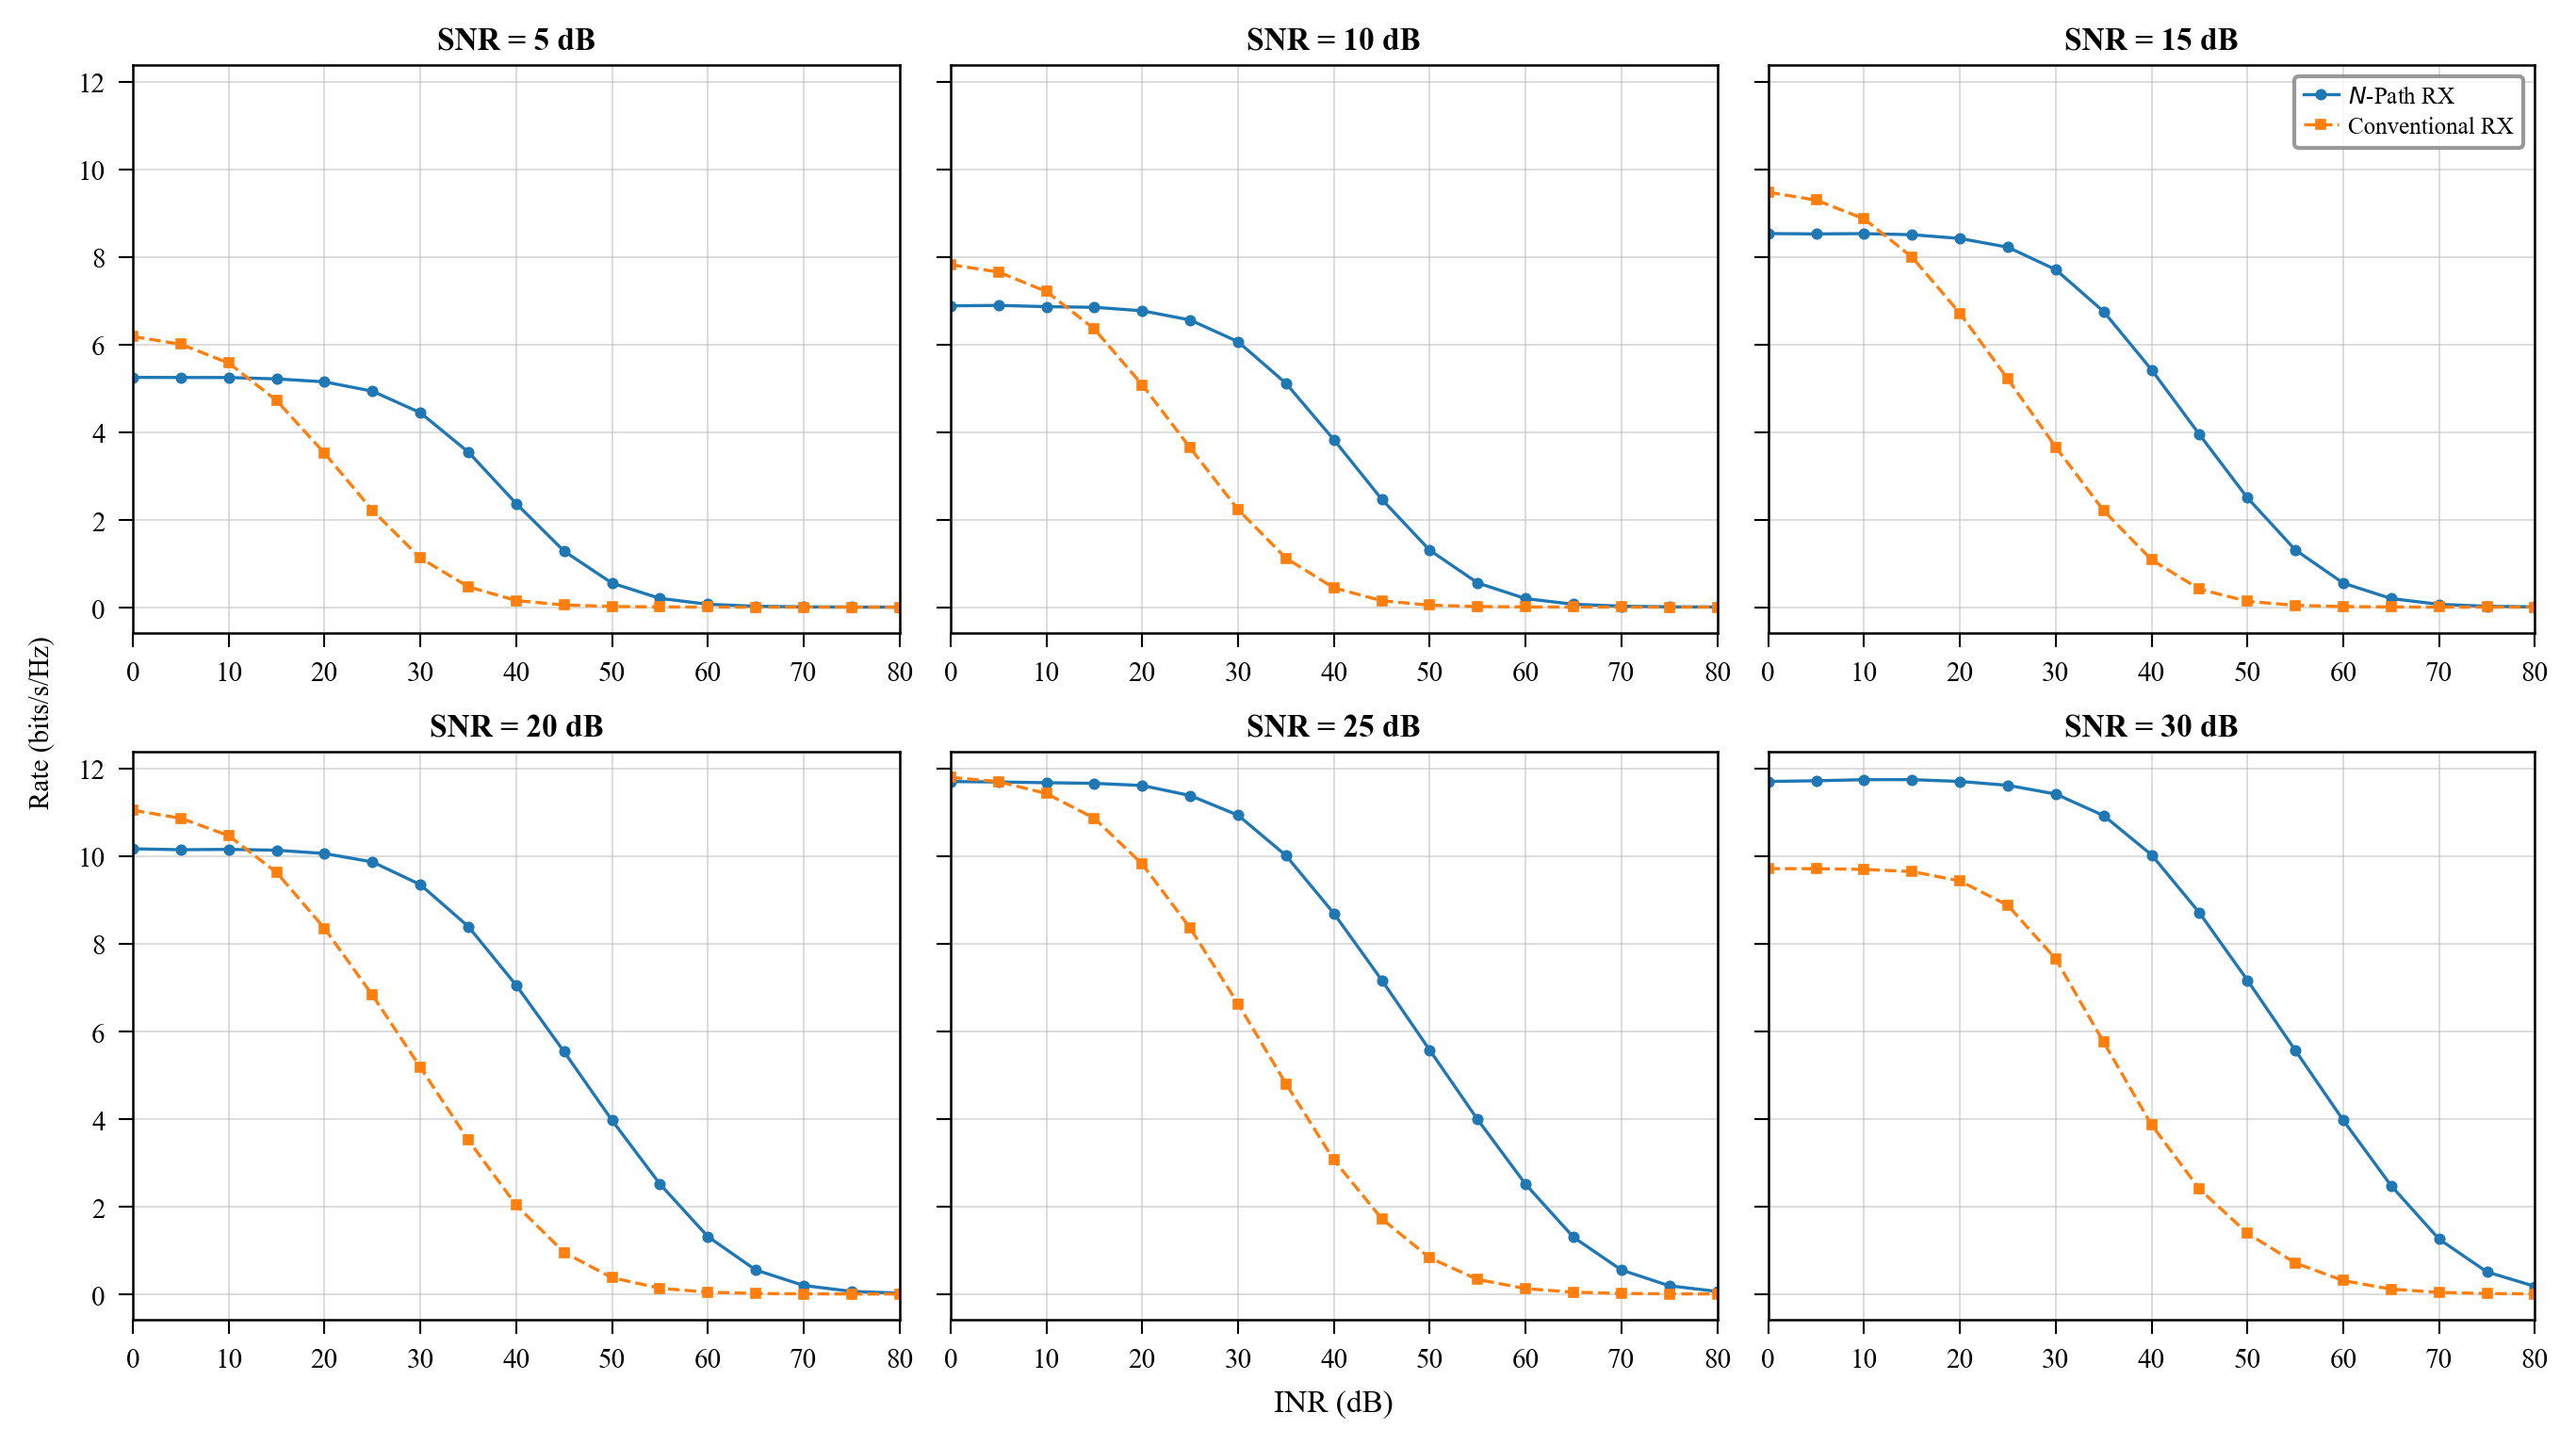

In [5]:
plot_rate("../results/data/4_path_data.csv")

[sim] SNR=10 dB  INR=0 dB
  Rate (bits/s/Hz) - N-path: 8.66 | Conv: 8.72
[sim] SNR=10 dB  INR=5 dB
  Rate (bits/s/Hz) - N-path: 8.65 | Conv: 8.41
[sim] SNR=10 dB  INR=10 dB
  Rate (bits/s/Hz) - N-path: 8.61 | Conv: 7.72
[sim] SNR=10 dB  INR=15 dB
  Rate (bits/s/Hz) - N-path: 8.45 | Conv: 6.58
[sim] SNR=10 dB  INR=20 dB
  Rate (bits/s/Hz) - N-path: 8.11 | Conv: 5.16
[sim] SNR=10 dB  INR=25 dB
  Rate (bits/s/Hz) - N-path: 7.38 | Conv: 3.65
[sim] SNR=10 dB  INR=30 dB
  Rate (bits/s/Hz) - N-path: 6.21 | Conv: 2.24
[sim] SNR=10 dB  INR=35 dB
  Rate (bits/s/Hz) - N-path: 4.77 | Conv: 1.11
[sim] SNR=10 dB  INR=40 dB
  Rate (bits/s/Hz) - N-path: 3.28 | Conv: 0.46
[sim] SNR=10 dB  INR=45 dB
  Rate (bits/s/Hz) - N-path: 1.93 | Conv: 0.16
[sim] SNR=10 dB  INR=50 dB
  Rate (bits/s/Hz) - N-path: 0.92 | Conv: 0.06
[sim] SNR=10 dB  INR=55 dB
  Rate (bits/s/Hz) - N-path: 0.36 | Conv: 0.03
[sim] SNR=10 dB  INR=60 dB
  Rate (bits/s/Hz) - N-path: 0.14 | Conv: 0.02
[sim] SNR=10 dB  INR=65 dB
  Rate (bits/

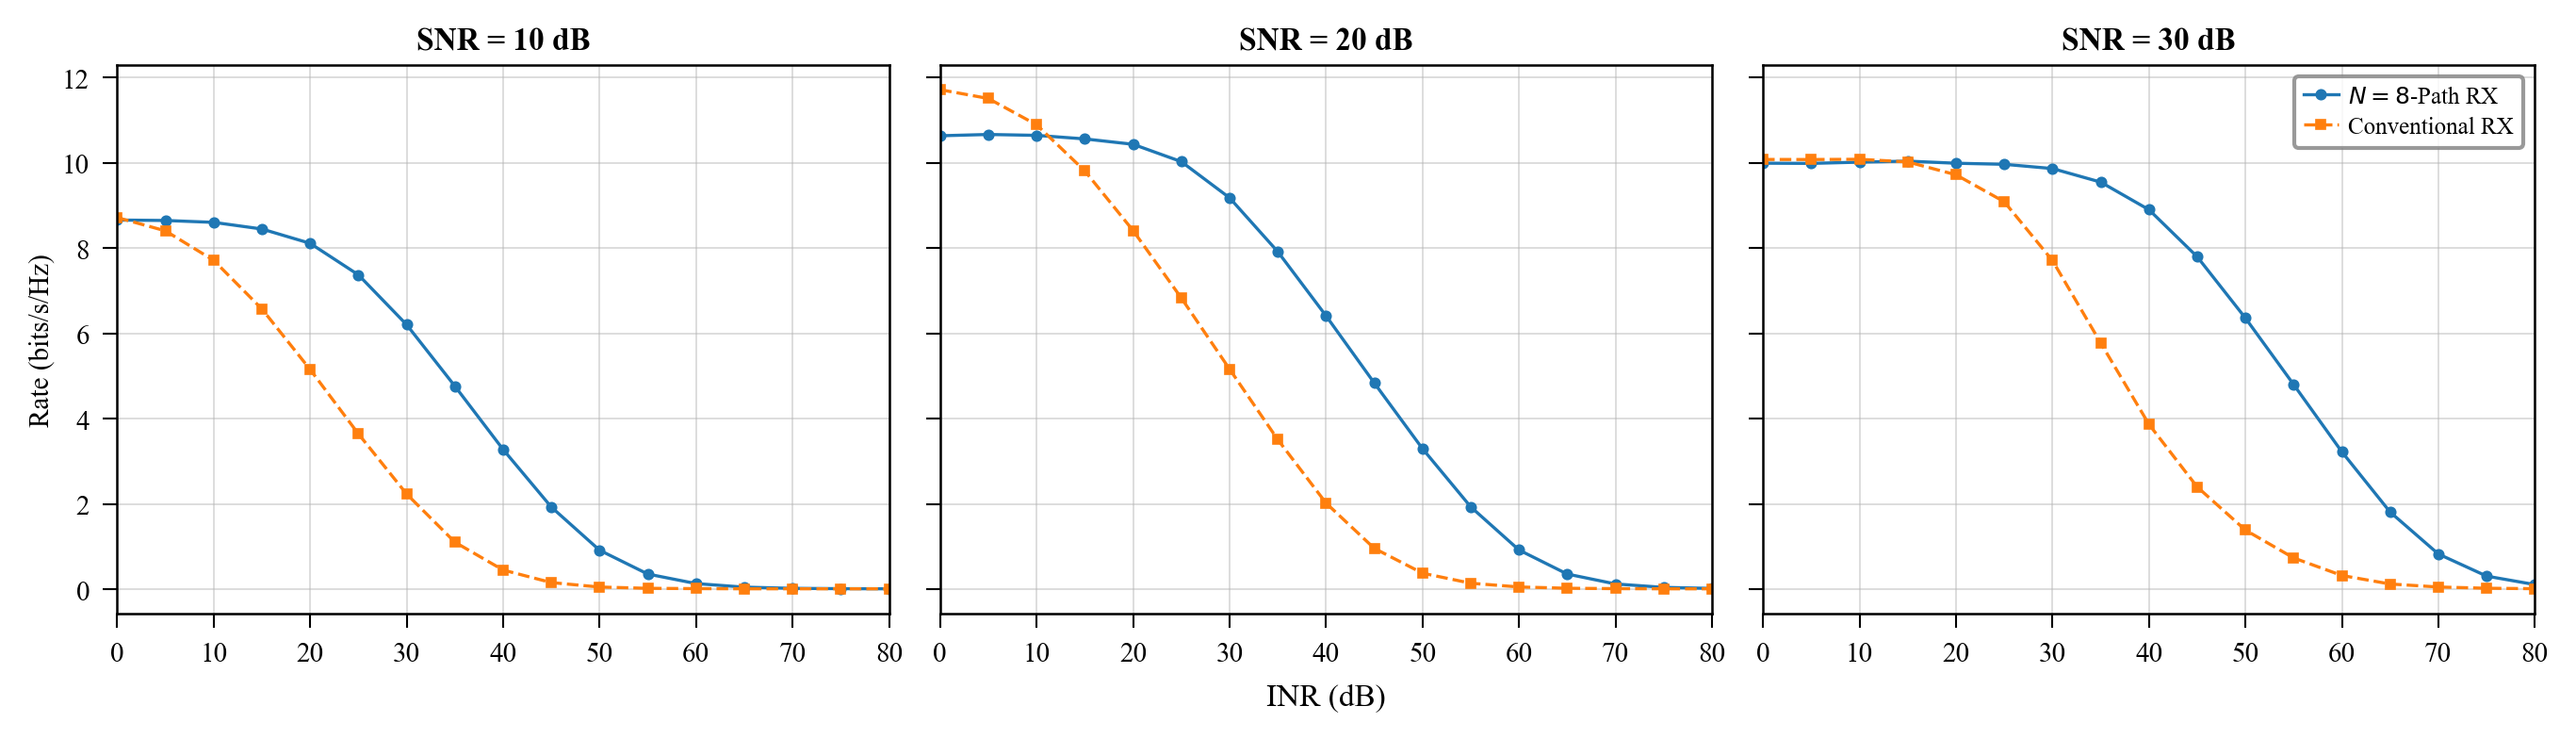

In [4]:
N=8
f_s=N*8e9
f_p2=10e9
f_c1=100e6
f_c2=400e6
Nsamp=100
f_adc=100e6
symmetry = True

SNR_db = np.arange(10, 31, 10)
INR_db = np.arange(0, 81, 5)

test = NPathRXTest(N=N, f_s=f_s, f_p2=f_p2, Nsamp=Nsamp,
                   f_c1=f_c1, f_c2=f_c2, symmetry=symmetry, f_adc=f_adc)


test.run(SNR_db, INR_db)
test.plot_rate(f"../results/data/{N}_path_data.csv")

[sim] SNR=5 dB  INR=0 dB
  Rate (bits/s/Hz) - N-path: 5.25 | Conv: 6.19
[sim] SNR=5 dB  INR=5 dB
  Rate (bits/s/Hz) - N-path: 5.25 | Conv: 6.01
[sim] SNR=5 dB  INR=10 dB
  Rate (bits/s/Hz) - N-path: 5.25 | Conv: 5.58
[sim] SNR=5 dB  INR=15 dB
  Rate (bits/s/Hz) - N-path: 5.22 | Conv: 4.73
[sim] SNR=5 dB  INR=20 dB
  Rate (bits/s/Hz) - N-path: 5.15 | Conv: 3.52
[sim] SNR=5 dB  INR=25 dB
  Rate (bits/s/Hz) - N-path: 4.94 | Conv: 2.22
[sim] SNR=5 dB  INR=30 dB
  Rate (bits/s/Hz) - N-path: 4.45 | Conv: 1.13
[sim] SNR=5 dB  INR=35 dB
  Rate (bits/s/Hz) - N-path: 3.55 | Conv: 0.48
[sim] SNR=5 dB  INR=40 dB
  Rate (bits/s/Hz) - N-path: 2.38 | Conv: 0.16
[sim] SNR=5 dB  INR=45 dB
  Rate (bits/s/Hz) - N-path: 1.29 | Conv: 0.06
[sim] SNR=5 dB  INR=50 dB
  Rate (bits/s/Hz) - N-path: 0.56 | Conv: 0.03
[sim] SNR=5 dB  INR=55 dB
  Rate (bits/s/Hz) - N-path: 0.21 | Conv: 0.02
[sim] SNR=5 dB  INR=60 dB
  Rate (bits/s/Hz) - N-path: 0.08 | Conv: 0.01
[sim] SNR=5 dB  INR=65 dB
  Rate (bits/s/Hz) - N-path

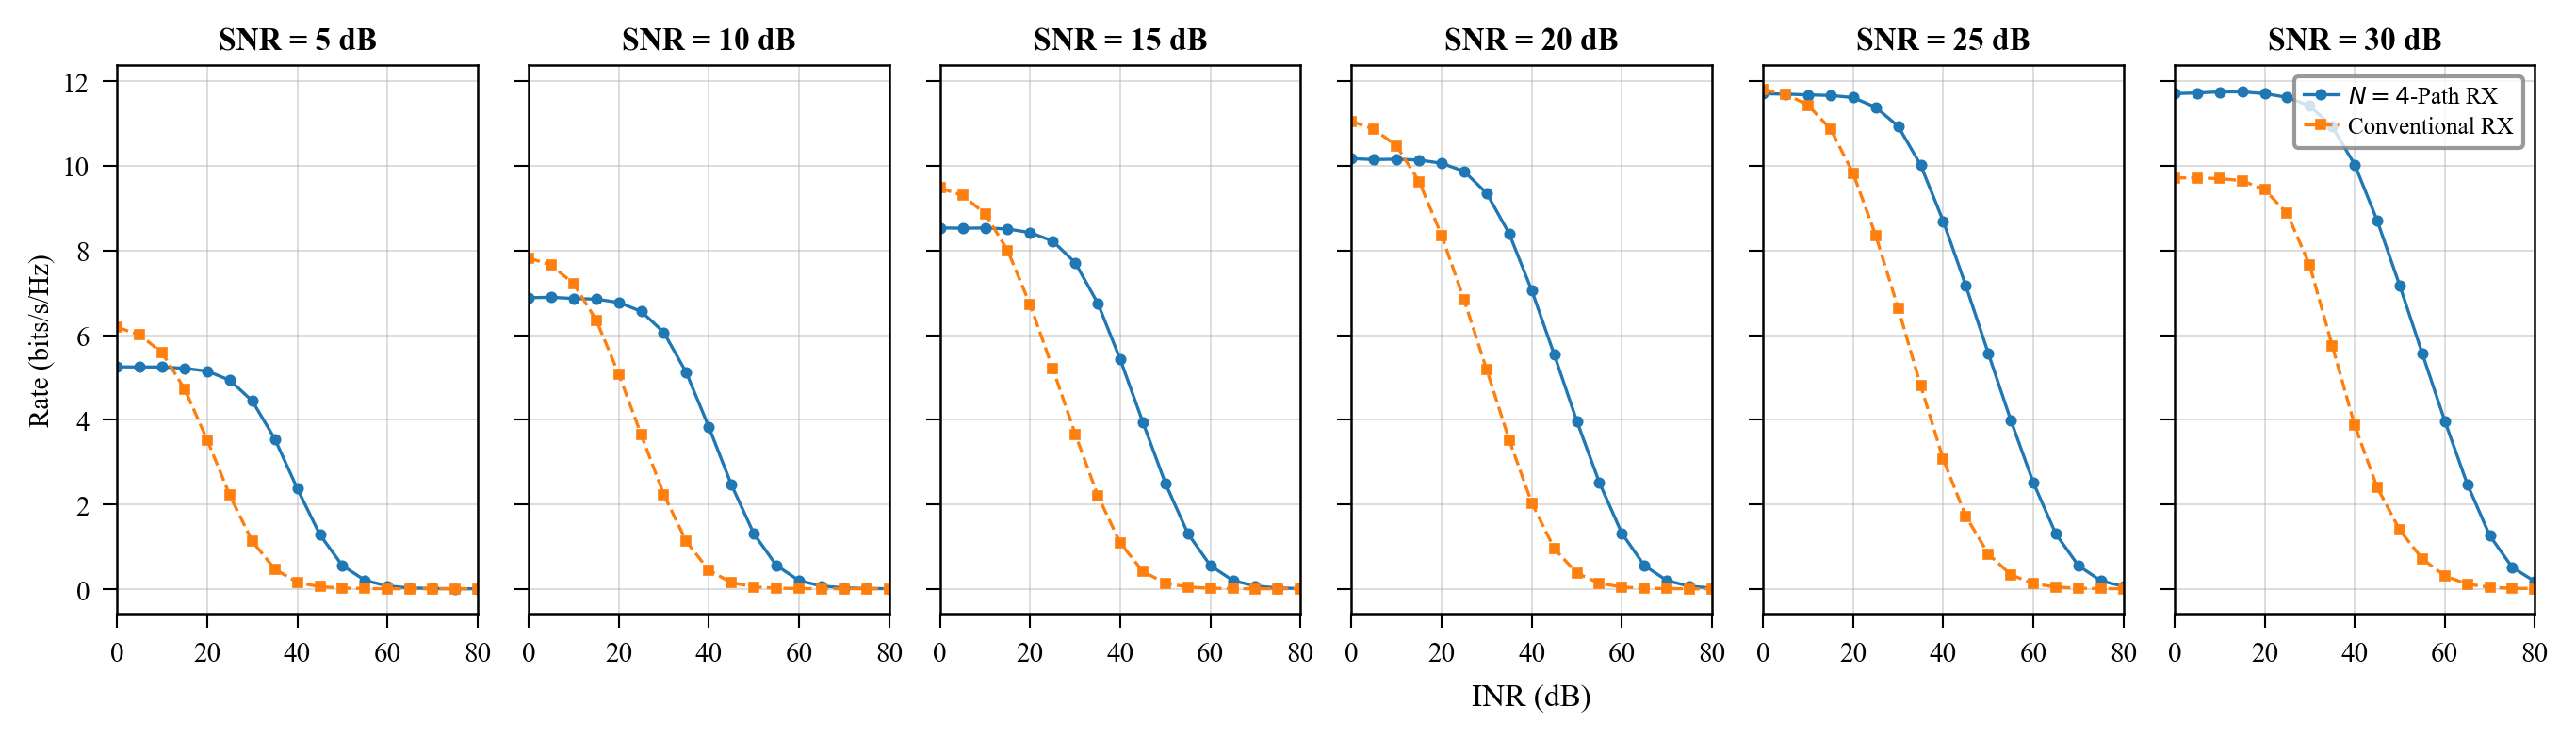

In [2]:
N=4
f_s=N*8e9
f_p2=10e9
f_c1=100e6
f_c2=400e6
Nsamp=120
f_adc=100e6
symmetry = True

SNR_db = np.arange(5, 31, 5)
INR_db = np.arange(0, 81, 5)

test = NPathRXTest(N=N, f_s=f_s, f_p2=f_p2, Nsamp=Nsamp,
                   f_c1=f_c1, f_c2=f_c2, symmetry=symmetry, f_adc=f_adc)

test.run(SNR_db, INR_db)
test.plot_rate(f"../results/data/{N}_path_data.csv")

System Parameters

In [ ]:
N=8
f_s=N*8e9
f_p2=10e9
f_c1=300e6
f_c2=600e6
Nsamp=100
f_adc=100e6
symmetry = True

SNR_db = np.arange(10, 31, 10)
INR_db = np.arange(0, 81, 5)

test = NPathRXTest(N=N, f_s=f_s, f_p2=f_p2, Nsamp=Nsamp,
                   f_c1=f_c1, f_c2=f_c2, symmetry=symmetry, f_adc=f_adc)

Signal Spectrum

Plot saved to ../results/plots/4_path_20_snr_20_inr_spectrum.pdf


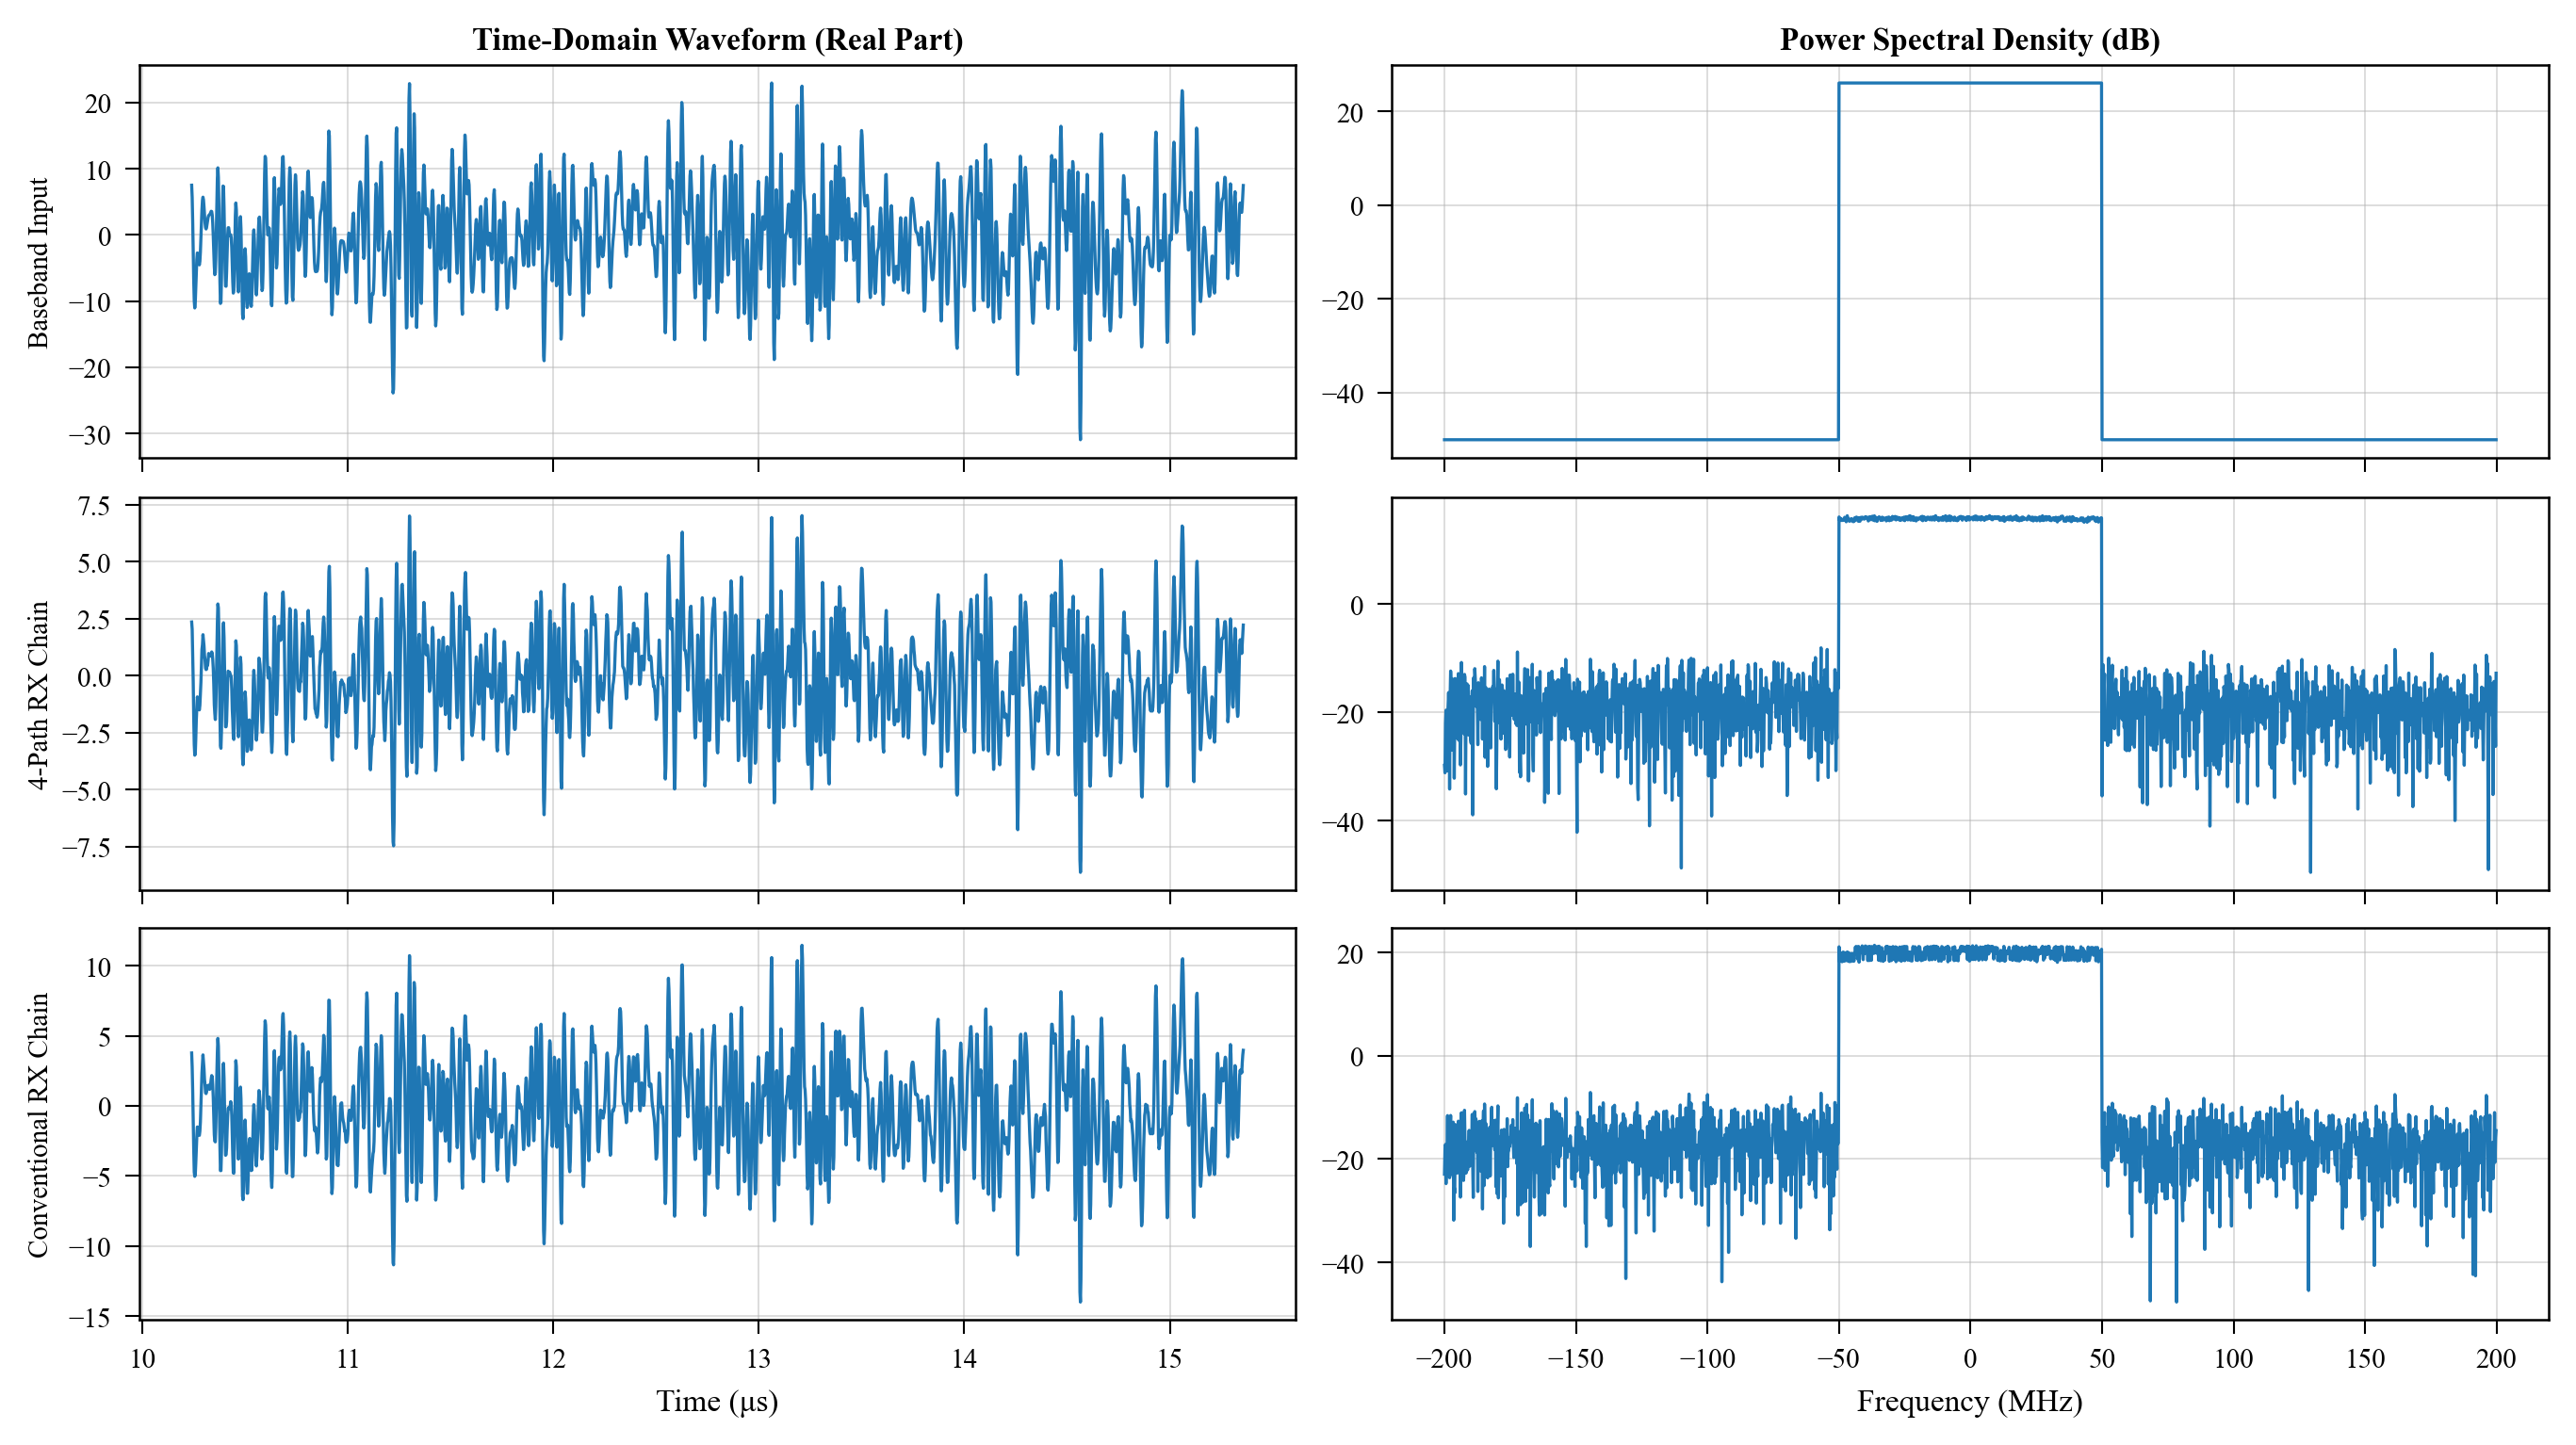

In [34]:
snr_db = 20
inr_db = 20

test.plot_spectrum(snr_db=snr_db,inr_db=inr_db)

Achievable Rate Plots

[sim] SNR=10 dB  INR=0 dB
  Rate (bits/s/Hz) - N-path: 5.63 | Conv: 6.46
[sim] SNR=10 dB  INR=5 dB
  Rate (bits/s/Hz) - N-path: 5.62 | Conv: 6.40
[sim] SNR=10 dB  INR=10 dB
  Rate (bits/s/Hz) - N-path: 5.63 | Conv: 6.28
[sim] SNR=10 dB  INR=15 dB
  Rate (bits/s/Hz) - N-path: 5.63 | Conv: 5.93
[sim] SNR=10 dB  INR=20 dB
  Rate (bits/s/Hz) - N-path: 5.60 | Conv: 5.16
[sim] SNR=10 dB  INR=25 dB
  Rate (bits/s/Hz) - N-path: 5.55 | Conv: 4.01
[sim] SNR=10 dB  INR=30 dB
  Rate (bits/s/Hz) - N-path: 5.37 | Conv: 2.66
[sim] SNR=10 dB  INR=35 dB
  Rate (bits/s/Hz) - N-path: 4.94 | Conv: 1.43
[sim] SNR=10 dB  INR=40 dB
  Rate (bits/s/Hz) - N-path: 4.10 | Conv: 0.62
[sim] SNR=10 dB  INR=45 dB
  Rate (bits/s/Hz) - N-path: 2.93 | Conv: 0.22
[sim] SNR=10 dB  INR=50 dB
  Rate (bits/s/Hz) - N-path: 1.74 | Conv: 0.07
[sim] SNR=10 dB  INR=55 dB
  Rate (bits/s/Hz) - N-path: 0.82 | Conv: 0.03
[sim] SNR=10 dB  INR=60 dB
  Rate (bits/s/Hz) - N-path: 0.32 | Conv: 0.02
[sim] SNR=10 dB  INR=65 dB
  Rate (bits/

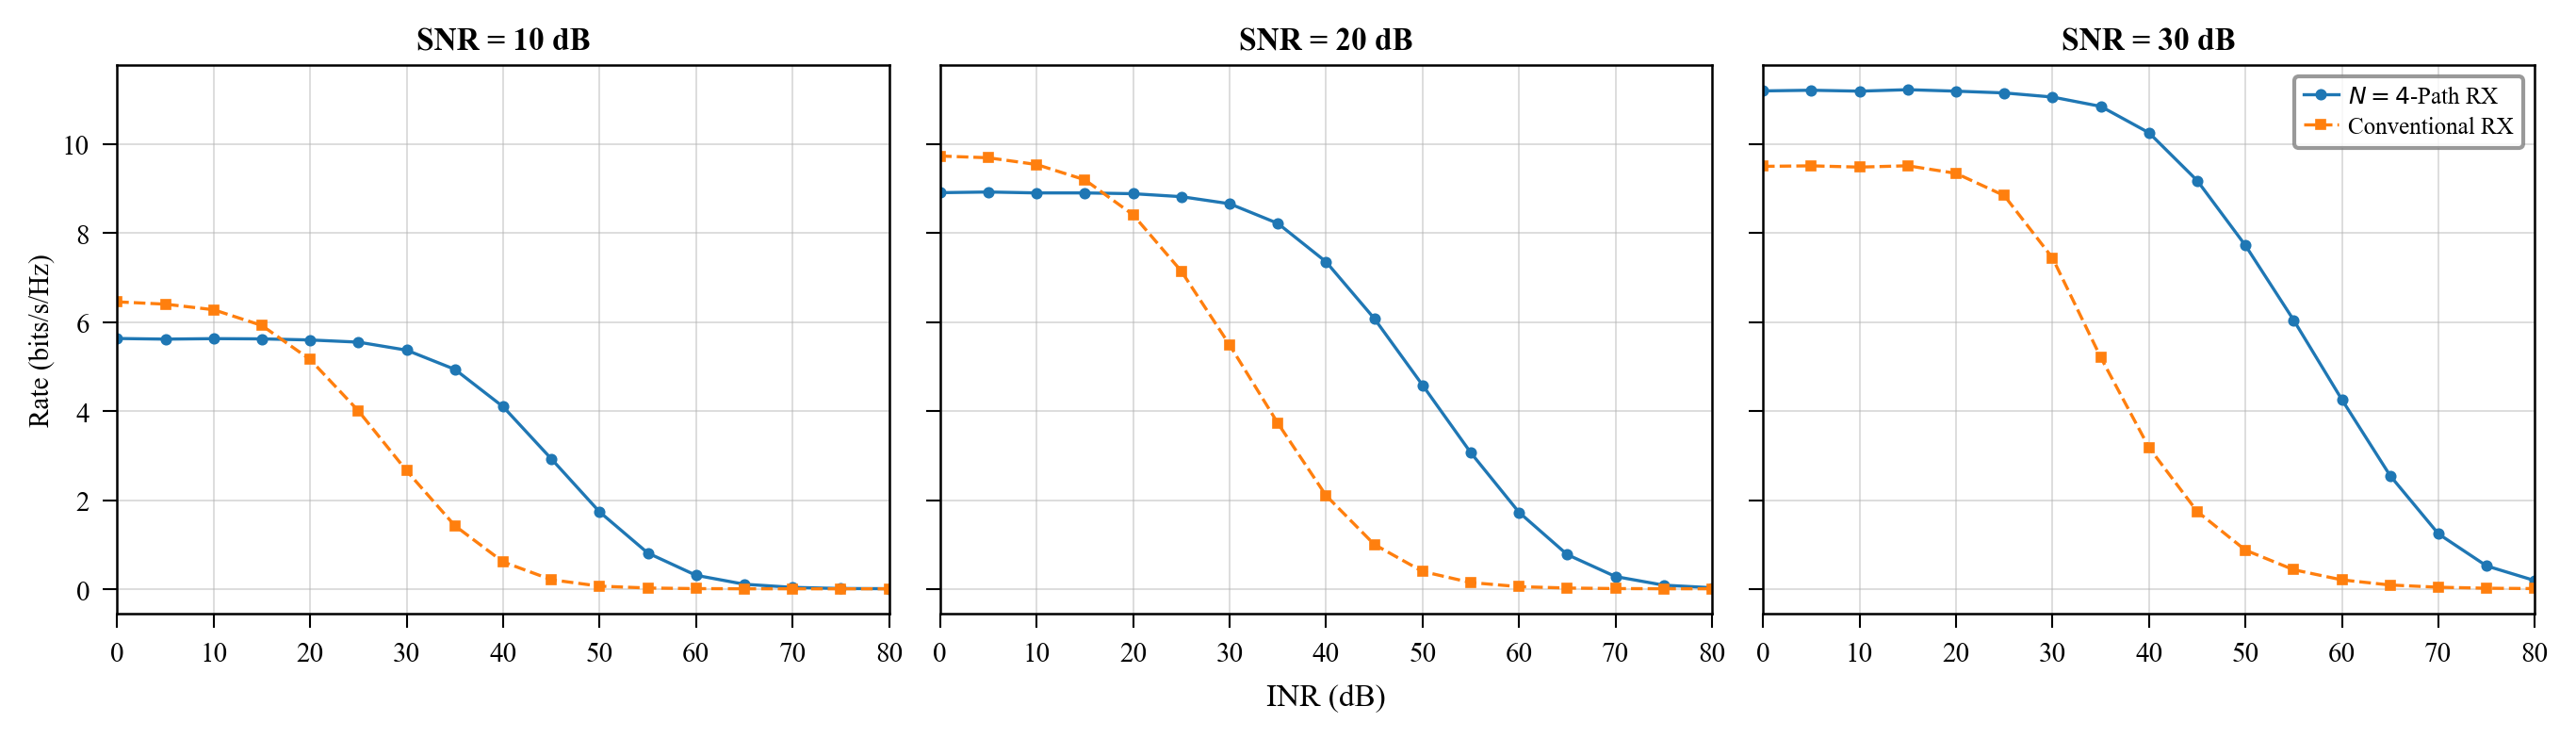

In [26]:
test.run(SNR_db, INR_db)
test.plot_rate(f"../results/data/{N}_path_data.csv")

Plot saved to ../results/plots/rate_vs_inr.pdf


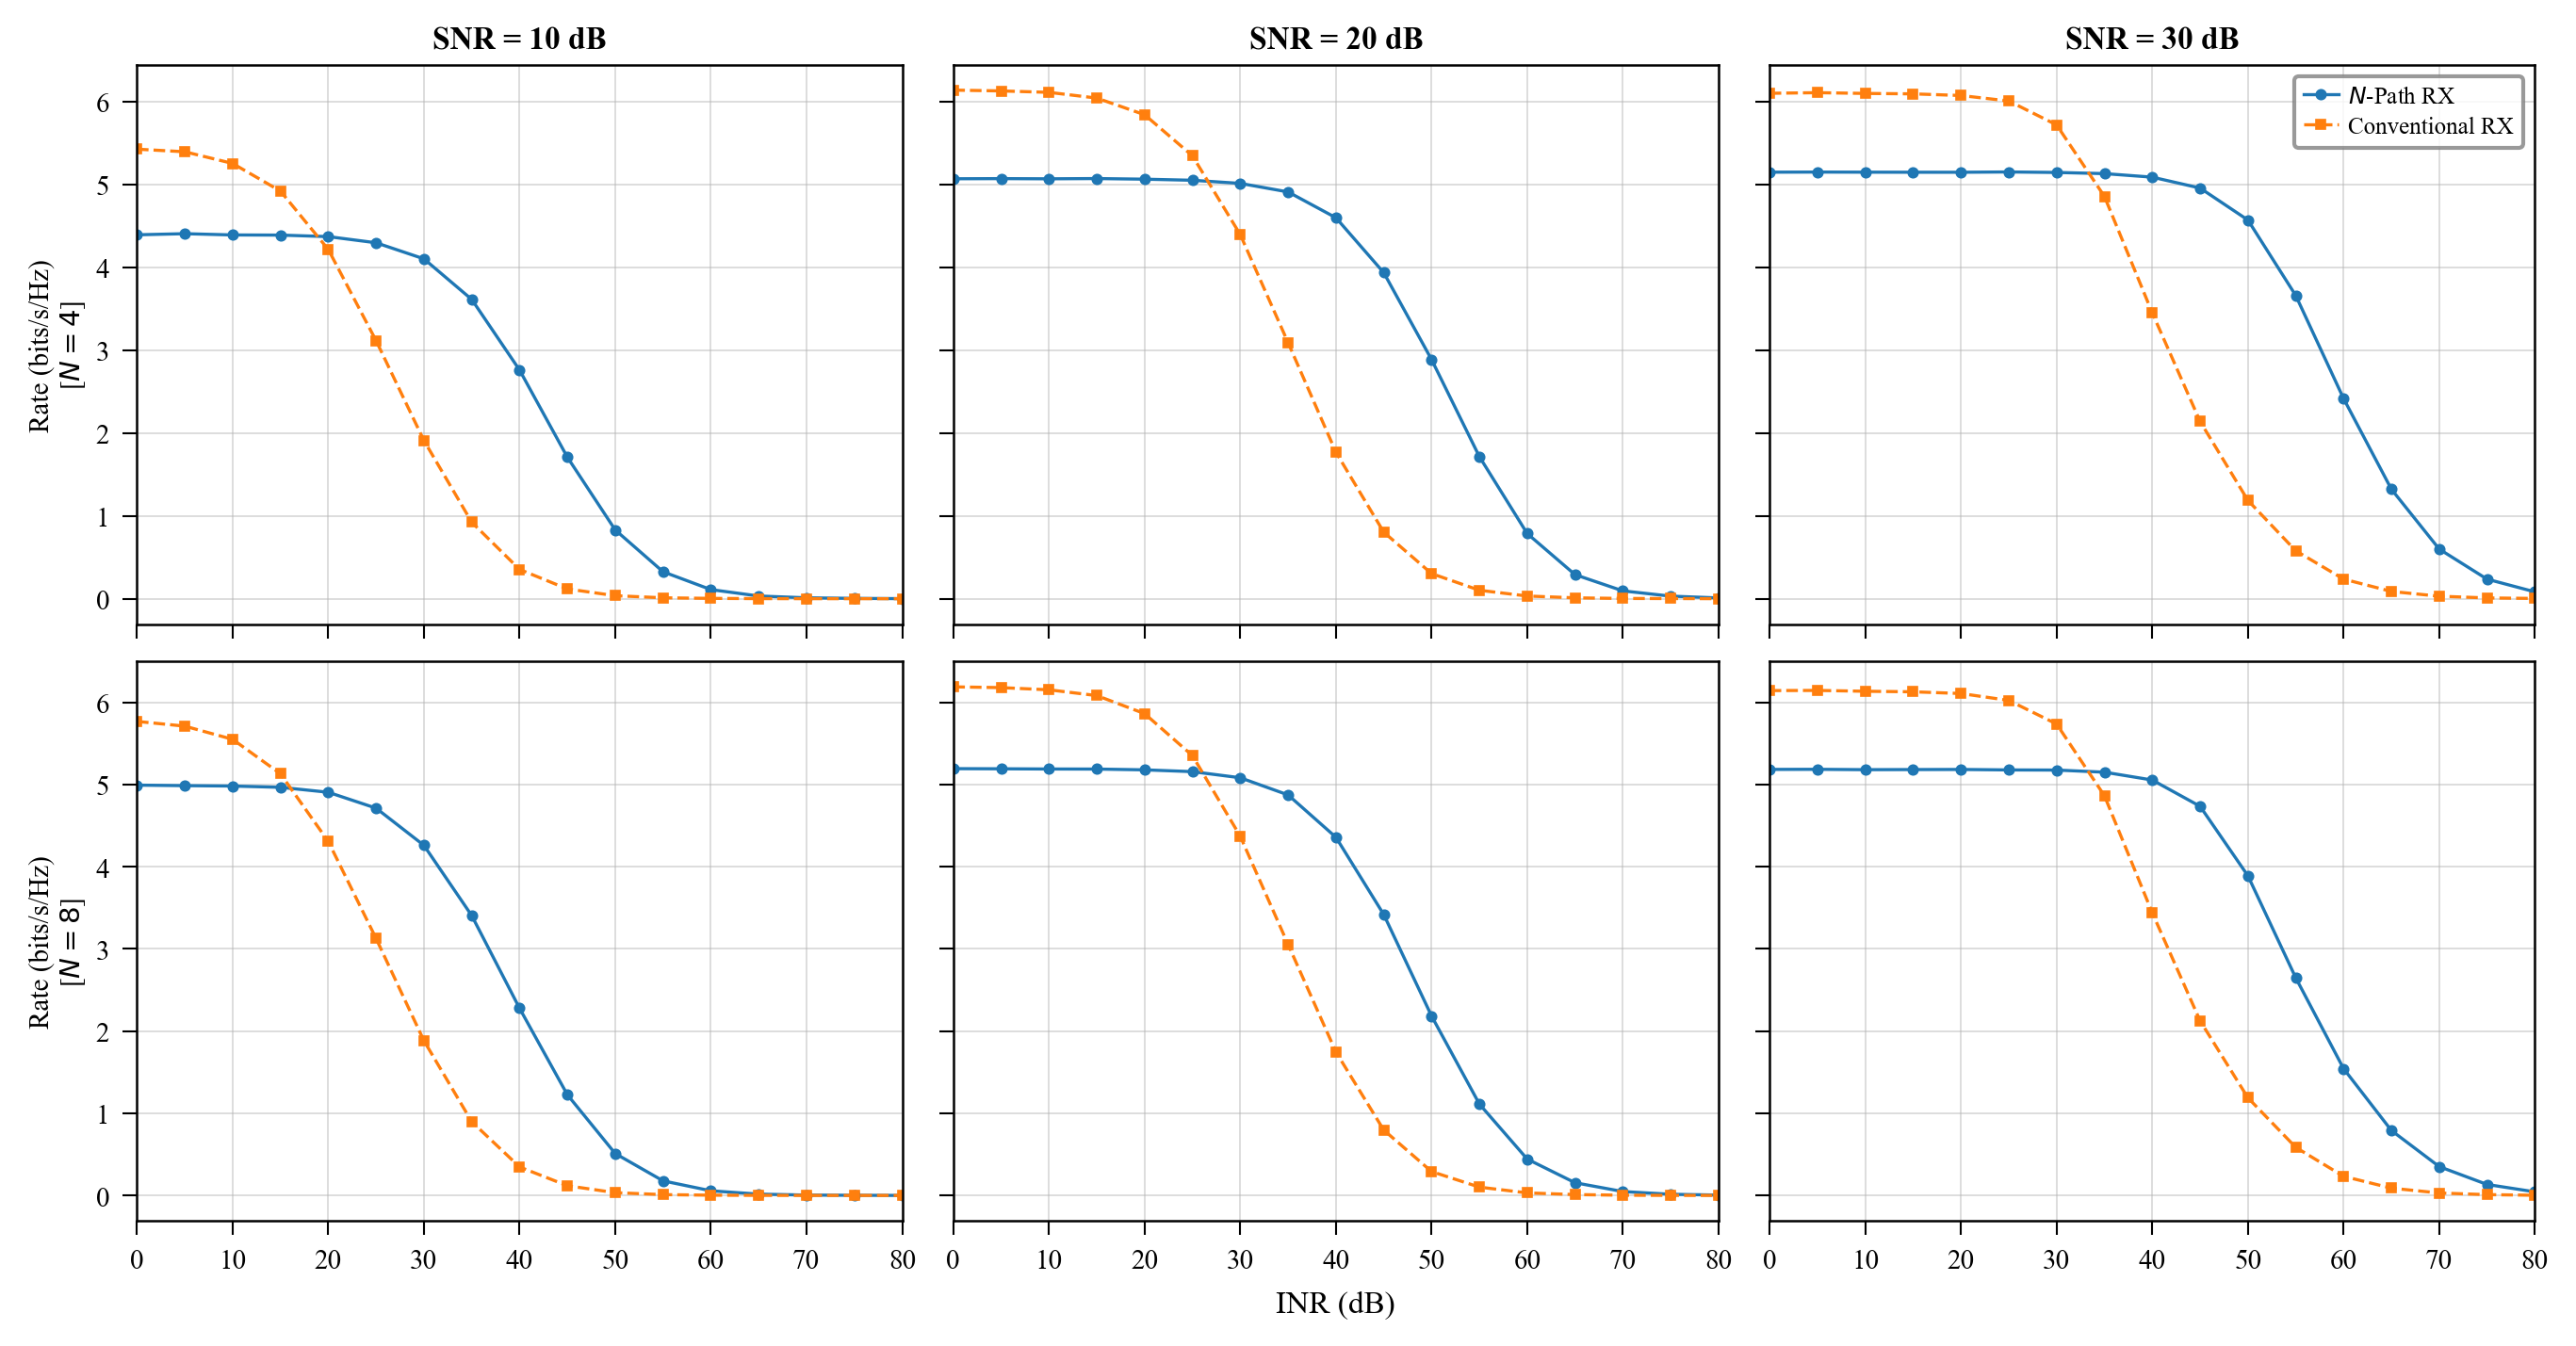

In [37]:
plot_rate_comparison("../results/data/4_path_data.csv", "../results/data/8_path_data.csv")